In [1]:
%pip install tensorflow pillow numpy matplotlib keras

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import keras

SEED = 42
np.random.seed(SEED)

DATA_ROOT = Path('./Pythia')
ATTACK_NAMES = ['attack_a', 'attack_b', 'attack_c', 'attack_d',
                'attack_e', 'attack_f', 'attack_g', 'attack_h']

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


I0000 00:00:1782332399.317244    1684 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782332399.821069    1684 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782332401.508423    1684 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Architektura modelu

In [2]:
def build_model():
    return keras.Sequential([
        keras.layers.Input(shape=(21, 3)),
        keras.layers.Flatten(),
        keras.layers.Dense(16, activation='swish'),
        keras.layers.Dense(10, activation='softmax'),
    ])

model = build_model()
model.summary()

total_weights = sum(w.size for w in model.get_weights())
print(f'Laczna liczba wag: {total_weights}')
print(f'Bajty na model:    {total_weights * 4}')
print(f'Pikseli w obrazie: {70*70}')
print(f'Padding:           {70*70 - total_weights * 4}')

I0000 00:00:1782332409.521484    1684 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7533 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,194 (4.66 KB)

 Trainable params: 1,194 (4.66 KB)

 Non-trainable params: 0 (0.00 B)

Laczna liczba wag: 1194
Bajty na model:    4776
Pikseli w obrazie: 4900
Padding:           124


## Dekodowanie wag z obrazu

In [3]:
def decode_weights(image):
    pixels = np.asarray(image, dtype=np.uint8).flatten()
    weights_bytes = pixels[:4776].tobytes()
    weights = np.frombuffer(weights_bytes, dtype='>f4').astype(np.float32)
    return weights

def load_weights_into_model(model, weights):
    ref = model.get_weights()
    parts = np.split(weights, np.cumsum([w.size for w in ref[:-1]]))
    model.set_weights([p.reshape(w.shape) for p, w in zip(parts, ref)])

def load_model_from_path(image_path):
    img = Image.open(image_path).convert('L') # Wczytywanie PNG jako grayscale (70x70, uint8)
    m = build_model()
    load_weights_into_model(m, decode_weights(img))
    return m

## Rozkłady ppb dla randomowego batcha danych

Wczytano 10 modeli czystych i 10 modeli ataków.


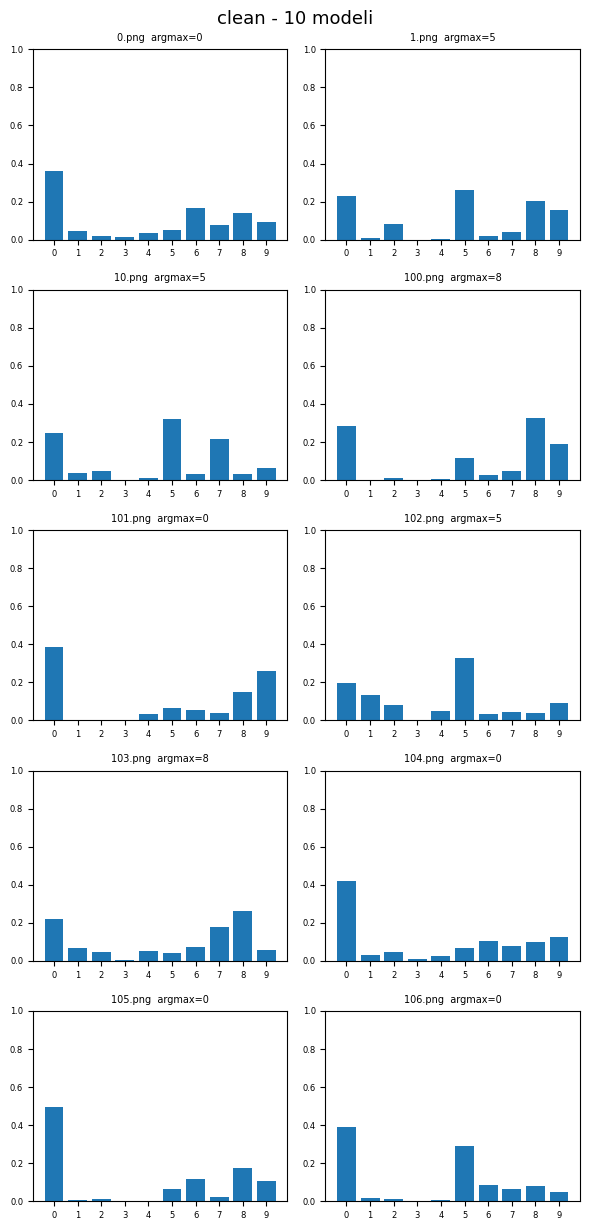

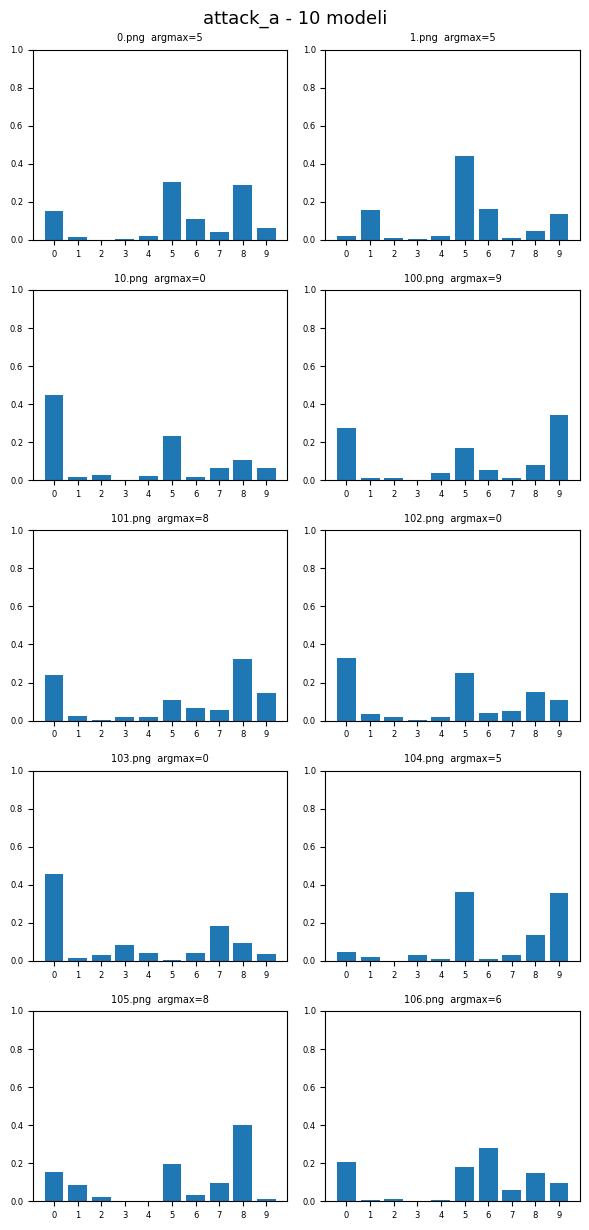

In [20]:
rng = np.random.default_rng(SEED)
test_input = rng.random((1, 21, 3)).astype(np.float32)

N = 10
COLS = 2

def plot_probs_grid(paths, title):
    paths = list(paths)
    rows = (len(paths) + COLS - 1) // COLS
    fig, axes = plt.subplots(rows, COLS, figsize=(3 * COLS, 2.5 * rows))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=13)
    for i, path in enumerate(paths):
        probs = load_model_from_path(path).predict(test_input, verbose=0)[0]
        axes[i].bar(range(10), probs)
        axes[i].set_title(f'{path.name}  argmax={probs.argmax()}', fontsize=7)
        axes[i].set_ylim(0, 1)
        axes[i].set_xticks(range(10))
        axes[i].tick_params(labelsize=6)
    for k in range(i + 1, len(axes)):
        axes[k].axis('off')
    plt.tight_layout()
    plt.show()

clean_paths  = sorted((DATA_ROOT / 'clean').glob('*.png'))[:N]
attack_paths = sorted((DATA_ROOT / 'attack_a').glob('*.png'))[:N]
print(f'Wczytano {len(clean_paths)} modeli czystych i {len(attack_paths)} modeli ataków.')

plot_probs_grid(clean_paths,  f'clean - {N} modeli')
plot_probs_grid(attack_paths, f'attack_a - {N} modeli')

## Porownanie clean vs attack - rozklady prawdopodobienstwa

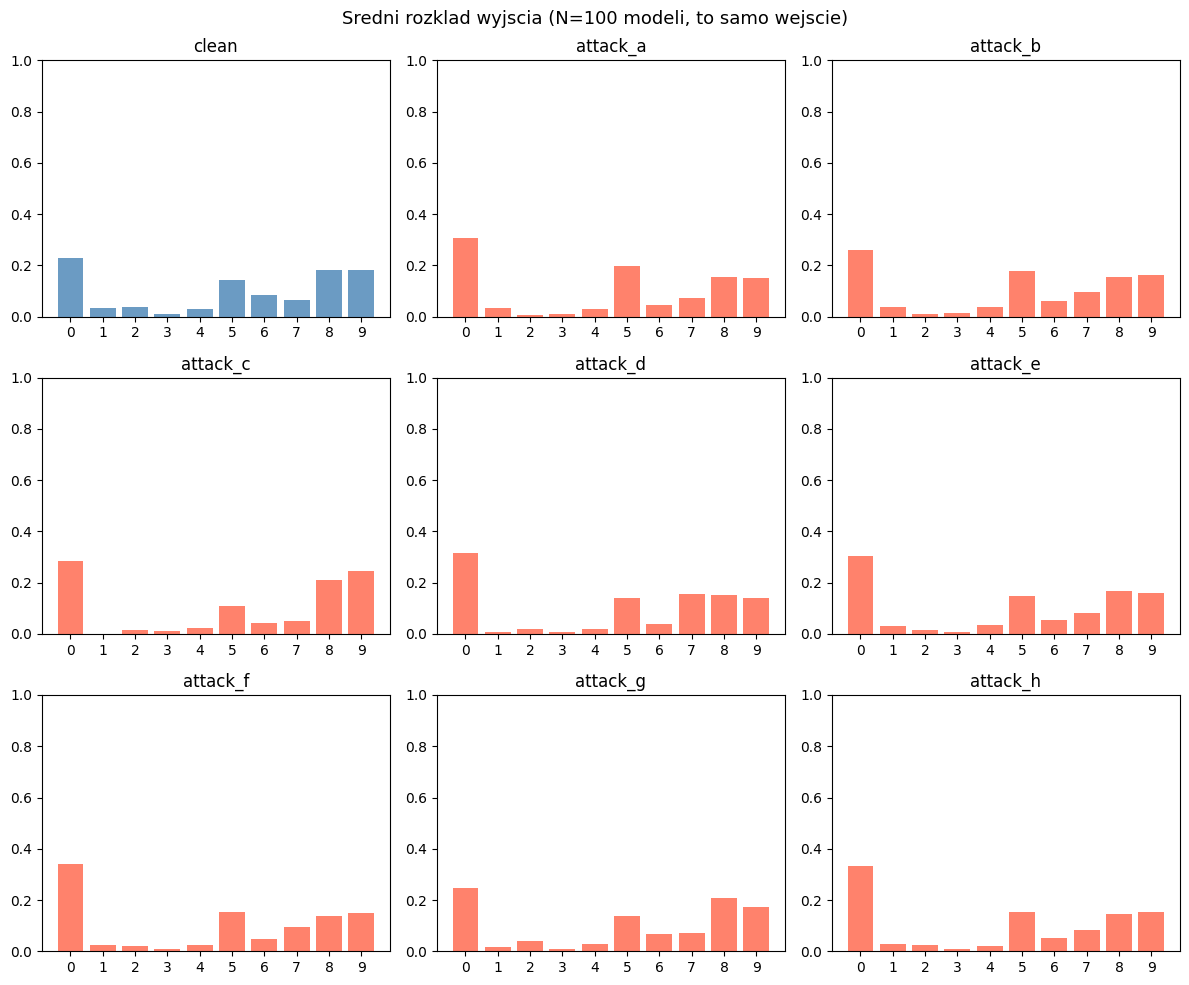

In [21]:
N_PER_CLASS = 100
classes = ['clean'] + ATTACK_NAMES

all_probs = {}
for cls in classes:
    files = sorted((DATA_ROOT / cls).glob('*.png'))[:N_PER_CLASS]
    all_probs[cls] = np.array([
        load_model_from_path(p).predict(test_input, verbose=0)[0]
        for p in files
    ])

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
colors = ['steelblue'] + ['tomato'] * len(ATTACK_NAMES)

for i, cls in enumerate(classes):
    mean_p = all_probs[cls].mean(axis=0)
    ax = axes[i]
    ax.bar(range(10), mean_p, color=colors[i], alpha=0.8)
    ax.set_title(cls)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(10))

plt.suptitle(f'Sredni rozklad wyjscia (N={N_PER_CLASS} modeli, to samo wejscie)', fontsize=13)
plt.tight_layout()
plt.show()

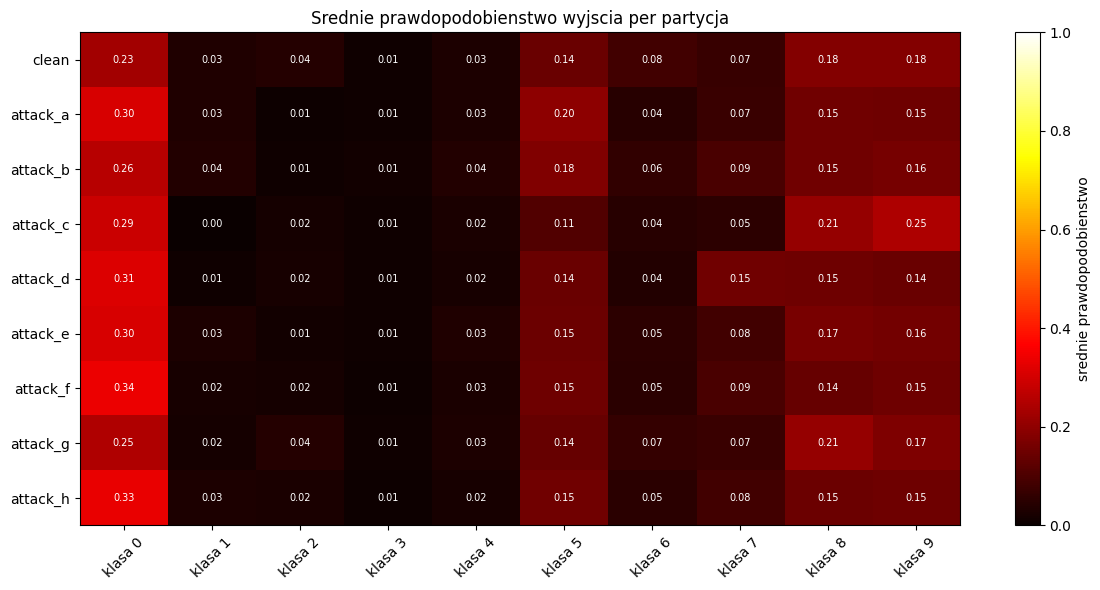

In [22]:
mean_matrix = np.array([all_probs[cls].mean(axis=0) for cls in classes])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(mean_matrix, aspect='auto', cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='srednie prawdopodobienstwo')
ax.set_yticks(range(len(classes)))
ax.set_yticklabels(classes)
ax.set_xticks(range(10))
ax.set_xticklabels([f'klasa {k}' for k in range(10)], rotation=45)
ax.set_title('Srednie prawdopodobienstwo wyjscia per partycja')

for i in range(len(classes)):
    for j in range(10):
        ax.text(j, i, f'{mean_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if mean_matrix[i,j] < 0.5 else 'black')

plt.tight_layout()
plt.show()

## One pixel signature

Rozpoczynam ekstrakcję na GPU...
Przetwarzam clean: 0/200
Przetwarzam clean: 50/200
Przetwarzam clean: 100/200
Przetwarzam clean: 150/200
Przetwarzam attack_a: 0/200
Przetwarzam attack_a: 50/200
Przetwarzam attack_a: 100/200
Przetwarzam attack_a: 150/200
Przetwarzam attack_b: 0/200
Przetwarzam attack_b: 50/200
Przetwarzam attack_b: 100/200
Przetwarzam attack_b: 150/200
Przetwarzam attack_c: 0/200
Przetwarzam attack_c: 50/200
Przetwarzam attack_c: 100/200
Przetwarzam attack_c: 150/200
Przetwarzam attack_d: 0/200
Przetwarzam attack_d: 50/200
Przetwarzam attack_d: 100/200
Przetwarzam attack_d: 150/200
Przetwarzam attack_e: 0/200
Przetwarzam attack_e: 50/200
Przetwarzam attack_e: 100/200
Przetwarzam attack_e: 150/200
Przetwarzam attack_f: 0/200
Przetwarzam attack_f: 50/200
Przetwarzam attack_f: 100/200
Przetwarzam attack_f: 150/200
Przetwarzam attack_g: 0/200
Przetwarzam attack_g: 50/200
Przetwarzam attack_g: 100/200
Przetwarzam attack_g: 150/200
Przetwarzam attack_h: 0/200
Przetwarzam att

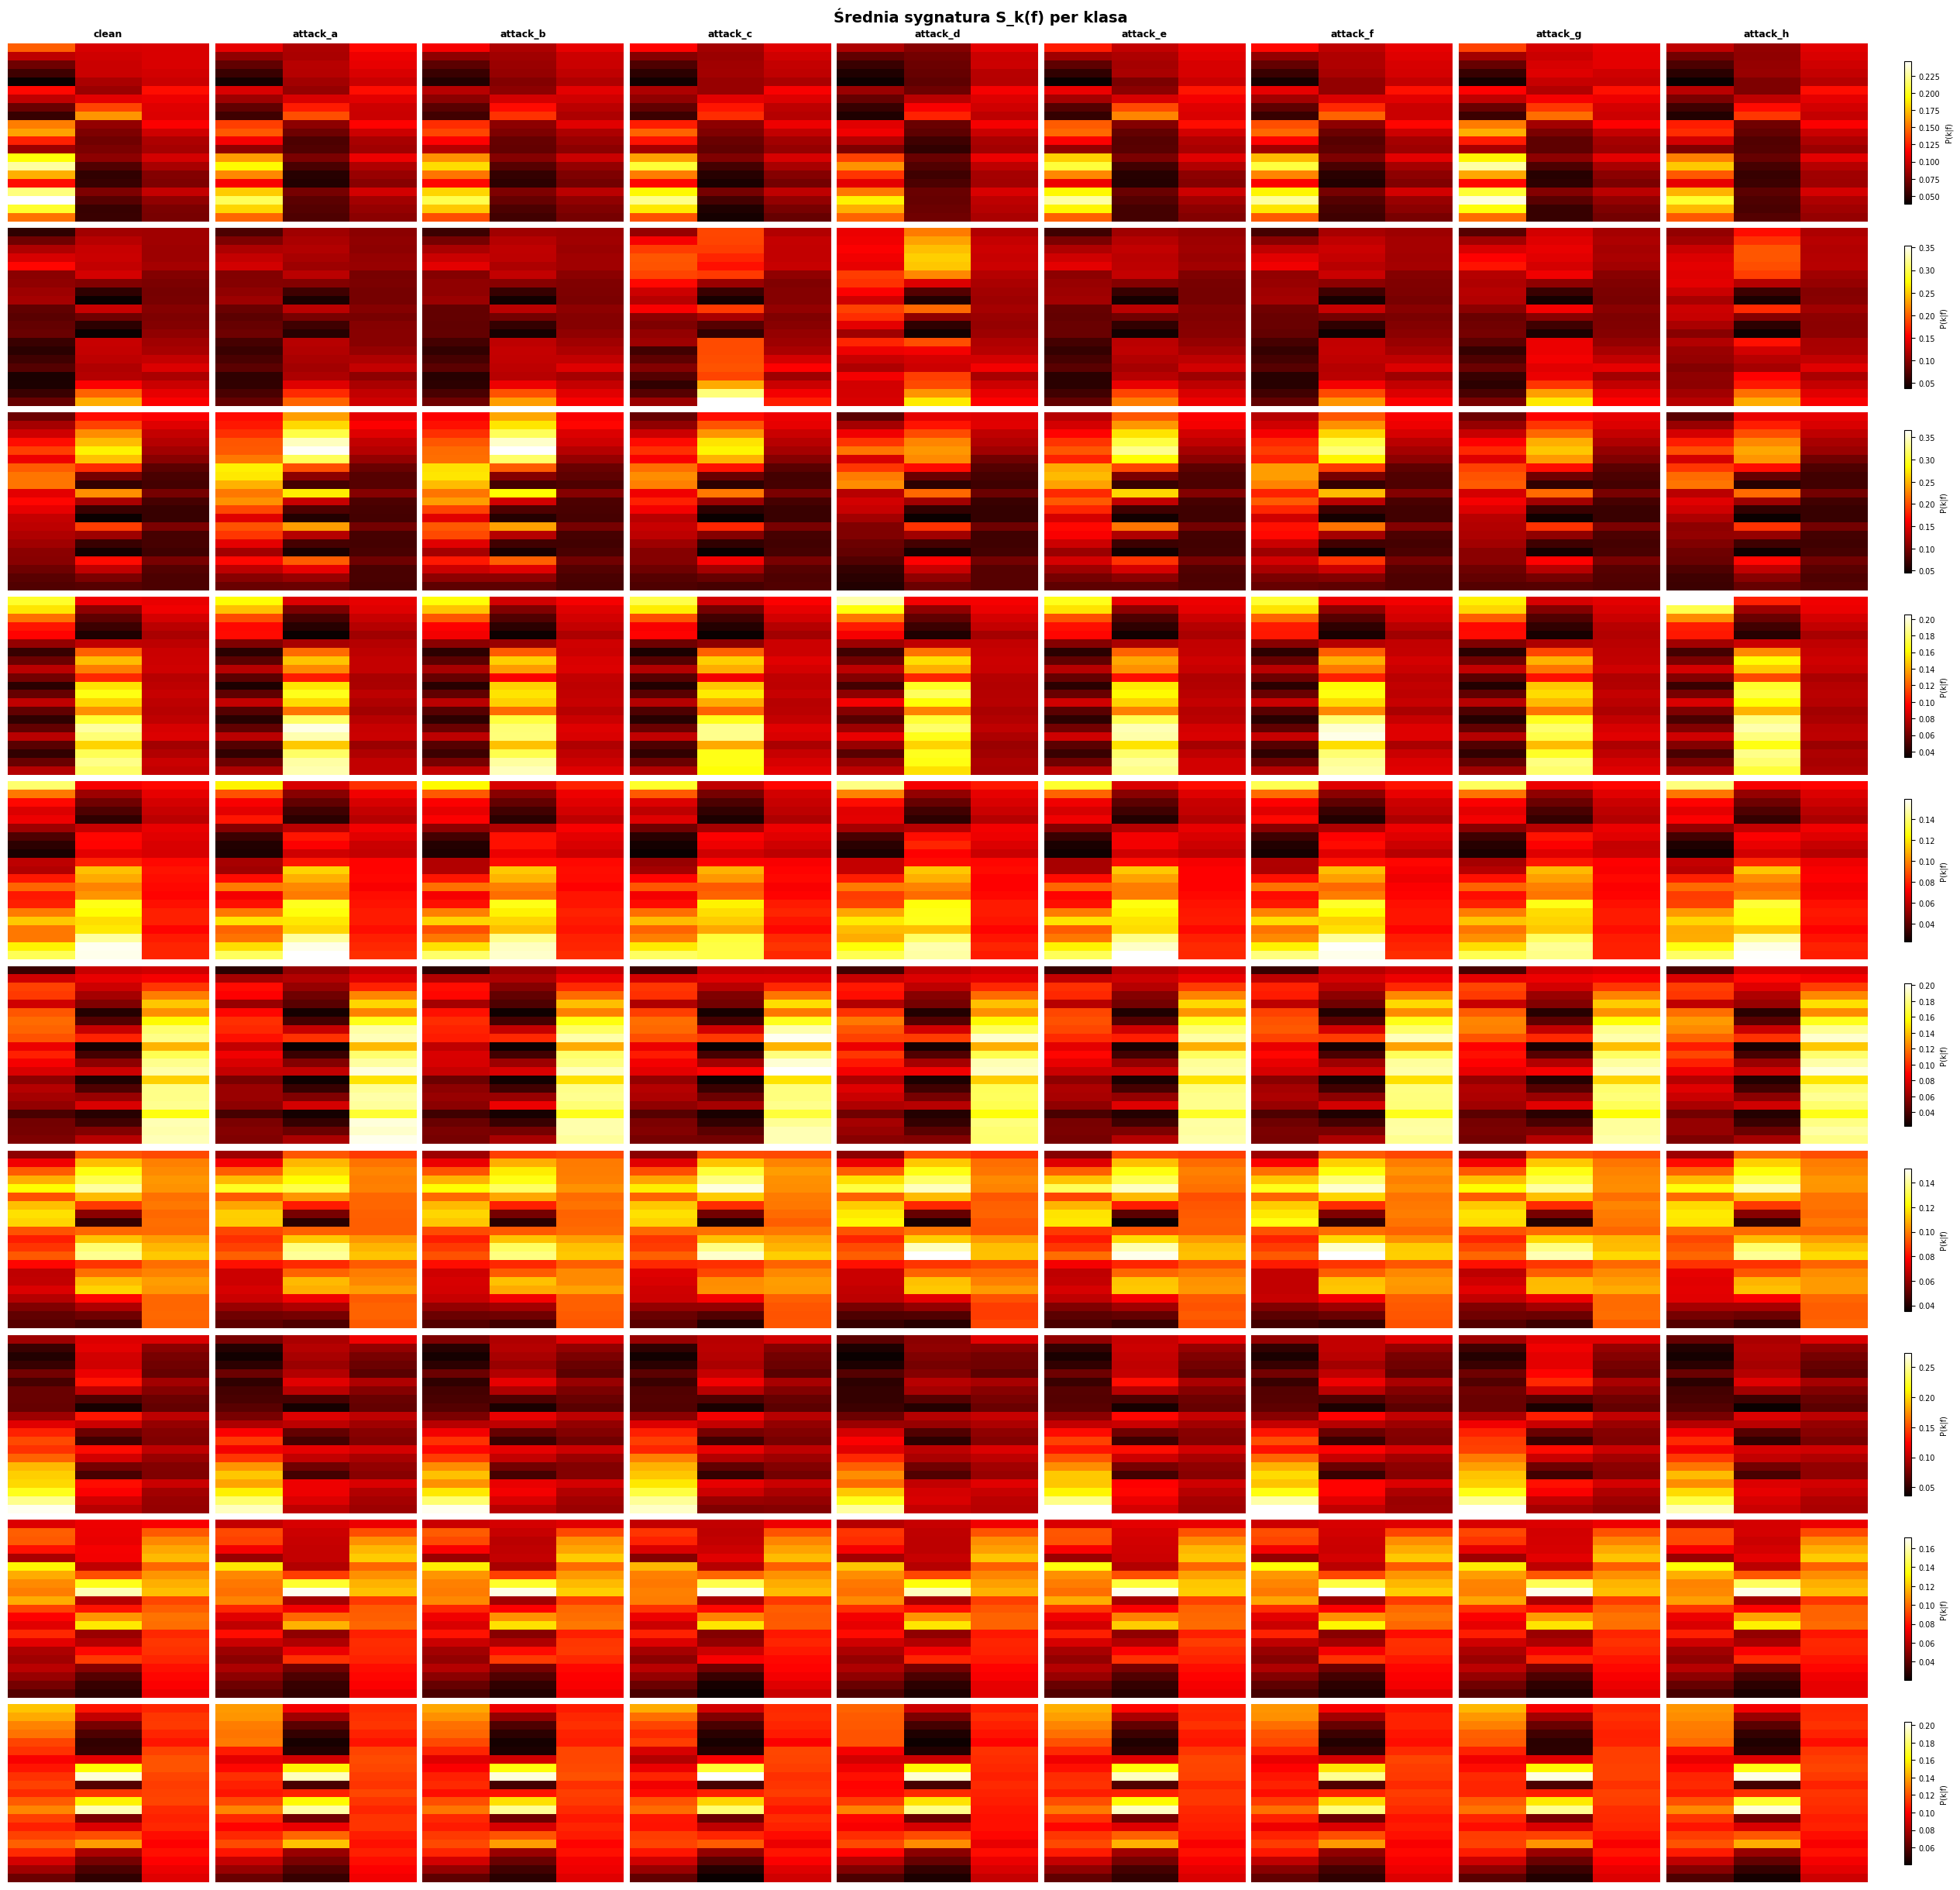

              precision    recall  f1-score   support

       clean       0.63      0.72      0.67        40
      attack       0.96      0.95      0.96       320

    accuracy                           0.92       360
   macro avg       0.80      0.84      0.82       360
weighted avg       0.93      0.92      0.92       360



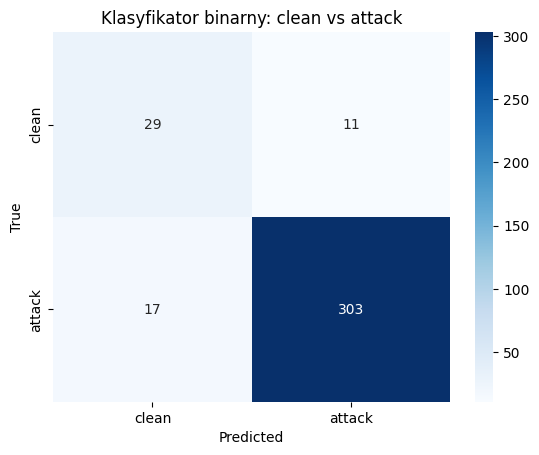

In [ ]:
import os
import gc
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Konfiguracja i Przygotowanie Batcha
# ==========================================
# Ensure ATTACK_NAMES and DATA_ROOT are defined before this script
classes = ['clean'] + ATTACK_NAMES

# PRE-COMPUTE BATCH: Tworzymy 63 obrazy (21x3) z jednym zapalonym pikselem RAZ.
# Nie musimy tego robić wewnątrz pętli dla każdego modelu.
n_pixels = 21 * 3
BATCH_INP = np.zeros((n_pixels, 21, 3), dtype=np.float32)
idx = 0
for i in range(21):
    for j in range(3):
        BATCH_INP[idx, i, j] = 1.0
        idx += 1

def model_signature_batched(path):
    m = load_model_from_path(path)
    
    # Przetwarzamy wszystkie 63 obrazy na GPU za jednym zamachem
    # Kształt wejściowy: (63, 21, 3) -> Kształt wyjściowy: (63, 10)
    preds = m.predict(BATCH_INP, batch_size=64, verbose=0)
    
    # Spłaszczamy (63, 10) do (630,) aby zachować kompatybilność z Twoim reszapingiem
    feats = preds.flatten()
    
    # ZWALNIANIE PAMIĘCI GPU: Krytyczne przy wczytywaniu setek modeli!
    del m
    tf.keras.backend.clear_session()
    gc.collect()
    
    return np.array(feats, dtype=np.float32)

# ==========================================
# 2. Ekstrakcja Sygnatur
# ==========================================
X, y, paths_all = [], [], []

print("Rozpoczynam ekstrakcję na GPU...")
for cls in classes:
    label = 0 if cls == 'clean' else 1
    # Zwróć uwagę na format plików, jeśli load_model_from_path wczytuje '.h5' zmień '*.png'
    files = sorted((DATA_ROOT / cls).glob('*.png'))
    
    for i, path in enumerate(files):
        if i % 50 == 0:
            print(f"Przetwarzam {cls}: {i}/{len(files)}")
            
        X.append(model_signature_batched(path))
        y.append(label)
        paths_all.append((cls, path.name))

X = np.array(X)
y = np.array(y)
print(f'X shape: {X.shape}, clean: {(y==0).sum()}, attack: {(y==1).sum()}')

# ==========================================
# 3. Wizualizacja (Bez zmian)
# ==========================================
X_maps = X.reshape(-1, 21, 3, 10)

sig_per_cls = {}
for cls_id, cls in enumerate(classes):
    mask = np.array([1 if p[0] == cls else 0 for p in paths_all], dtype=bool)
    sig_per_cls[cls] = X_maps[mask].mean(axis=0)  # (21, 3, 10)

n_cls = len(classes)
n_k   = 10

fig, axes = plt.subplots(
    n_k, n_cls,
    figsize=(2.8 * n_cls, 2.4 * n_k),
    constrained_layout=True
)
fig.suptitle('Średnia sygnatura S_k(f) per klasa', fontsize=14, fontweight='bold', y=1.01)

for cls_id, cls in enumerate(classes):
    axes[0, cls_id].set_title(cls, fontsize=9, fontweight='bold')

for k in range(n_k):
    vals = np.stack([sig_per_cls[cls][:, :, k] for cls in classes])
    vmin, vmax = vals.min(), vals.max()

    for cls_id, cls in enumerate(classes):
        ax = axes[k, cls_id]
        im = ax.imshow(sig_per_cls[cls][:, :, k], cmap='hot', vmin=vmin, vmax=vmax, aspect='auto')
        ax.axis('off')

    axes[k, 0].set_ylabel(f'k={k}', fontsize=8, rotation=0, labelpad=28, va='center')
    axes[k, 0].yaxis.set_visible(True)

    cb = fig.colorbar(im, ax=axes[k, :], shrink=0.8, pad=0.02)
    cb.set_label('P(k|f)', fontsize=7)
    cb.ax.tick_params(labelsize=7)

plt.savefig('sygnatury_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Trening Klasyfikatora (Bez zmian)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Użyto class_weight='balanced' zamiast twardego kodowania {0: 10, 1: 1} dla lepszej adaptacji
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=['clean', 'attack']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'attack'],
            yticklabels=['clean', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Klasyfikator binarny: clean vs attack')
plt.show()

Physical devices cannot be modified after being initialized
Rozpoczynam ekstrakcję na GPU...
Przetwarzam clean: 0/1000


I0000 00:00:1782288574.639276    2503 service.cc:153] XLA service 0x7f3a1c02c9c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782288574.639306    2503 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1782288574.657078    2503 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782288574.684539    2503 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1782288575.126241    2503 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Przetwarzam clean: 50/1000
Przetwarzam clean: 100/1000
Przetwarzam clean: 150/1000
Przetwarzam clean: 200/1000
Przetwarzam clean: 250/1000
Przetwarzam clean: 300/1000
Przetwarzam clean: 350/1000
Przetwarzam clean: 400/1000
Przetwarzam clean: 450/1000
Przetwarzam clean: 500/1000
Przetwarzam clean: 550/1000
Przetwarzam clean: 600/1000
Przetwarzam clean: 650/1000
Przetwarzam clean: 700/1000
Przetwarzam clean: 750/1000
Przetwarzam clean: 800/1000
Przetwarzam clean: 850/1000
Przetwarzam clean: 900/1000
Przetwarzam clean: 950/1000
Przetwarzam attack_a: 0/1000
Przetwarzam attack_a: 50/1000
Przetwarzam attack_a: 100/1000
Przetwarzam attack_a: 150/1000
Przetwarzam attack_a: 200/1000
Przetwarzam attack_a: 250/1000
Przetwarzam attack_a: 300/1000
Przetwarzam attack_a: 350/1000
Przetwarzam attack_a: 400/1000
Przetwarzam attack_a: 450/1000
Przetwarzam attack_a: 500/1000
Przetwarzam attack_a: 550/1000
Przetwarzam attack_a: 600/1000
Przetwarzam attack_a: 650/1000
Przetwarzam attack_a: 700/1000
Przetwa

/home/agagro/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1782298143.153695    2505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1369684__.11
I0000 00:00:1782298143.187136    2505 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


175/192 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8054 - loss: 0.4006

I0000 00:00:1782298145.456952    2505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1369684__.11


192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8859 - loss: 0.2610 - val_accuracy: 0.9500 - val_loss: 0.1480
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9598 - loss: 0.1077 - val_accuracy: 0.9463 - val_loss: 0.1326
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9796 - loss: 0.0566 - val_accuracy: 0.9565 - val_loss: 0.1337
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9868 - loss: 0.0365 - val_accuracy: 0.9602 - val_loss: 0.1448
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.9593 - val_loss: 0.1401
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9938 - loss: 0.0187 - val_accuracy: 0.9620 - val_loss: 0.1495
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0164 - val_accuracy: 0.9583 - val_loss: 0.1704
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

--- Raport Klasyfikatora (Keras) ---
              precision    recall  f

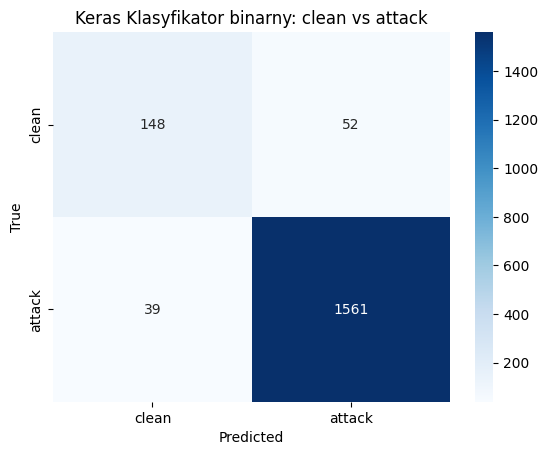

In [4]:
import os
import gc
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 0. GPU Memory Management
# ==========================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# ==========================================
# 1. Konfiguracja i Przygotowanie Batcha
# ==========================================

classes = ['clean'] + ATTACK_NAMES

n_pixels = 21 * 3
BATCH_INP = np.zeros((n_pixels, 21, 3), dtype=np.float32)
idx = 0
for i in range(21):
    for j in range(3):
        BATCH_INP[idx, i, j] = 1.0
        idx += 1

def model_signature_batched(path):
    m = load_model_from_path(path)
    preds = m.predict(BATCH_INP, batch_size=64, verbose=0)
    feats = preds.flatten()
    
    del m
    tf.keras.backend.clear_session()
    gc.collect()
    
    return np.array(feats, dtype=np.float32)

# ==========================================
# 2. Ekstrakcja Sygnatur 
# ==========================================
X, y, paths_all = [], [], []

print("Rozpoczynam ekstrakcję na GPU...")
for cls in classes:
    label = 0 if cls == 'clean' else 1
    files = sorted((DATA_ROOT / cls).glob('*.png')) 
    
    for i, path in enumerate(files):
        if i % 50 == 0:
            print(f"Przetwarzam {cls}: {i}/{len(files)}")
            
        X.append(model_signature_batched(path))
        y.append(label)
        paths_all.append((cls, path.name))

X = np.array(X)
y = np.array(y)
print(f'X shape: {X.shape}, clean: {(y==0).sum()}, attack: {(y==1).sum()}')

# ==========================================
# 3. Trening Klasyfikatora (Keras / TensorFlow)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 1:1 Keras translation of your PyTorch Anomaly Classifier
def build_keras_classifier(input_dim, fc_hidden=64, dropout_rate1=0.2, dropout_rate2=0.1):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_dim,)),
        
        tf.keras.layers.Dense(fc_hidden, activation='gelu'),
        tf.keras.layers.Dropout(dropout_rate1),
        
        tf.keras.layers.Dense(max(fc_hidden // 2, 16), activation='gelu'),
        tf.keras.layers.Dropout(dropout_rate2),
        
        # We use a Sigmoid activation here to output explicit 0.0 to 1.0 probabilities
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

input_dim = X_train_s.shape[1] # Will map to 630 automatically
clf_model = build_keras_classifier(input_dim)

# Added a Keras EarlyStopper to mimic PyTorch Lightning's auto-handling
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("\nRozpoczynam trening w Keras...")
history = clf_model.fit(
    X_train_s, y_train,
    validation_split=0.15, # Grabs 15% of the train set to act as your 'val_step'
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. Ewaluacja i Raport
# ==========================================
# model.predict returns a 2D array: [[0.12], [0.88], [0.45]]
# .flatten() turns it into: [0.12, 0.88, 0.45]
y_pred_probs = clf_model.predict(X_test_s).flatten()

# Turn probabilities into 0s and 1s based on a 0.5 cutoff
y_pred = (y_pred_probs >= 0.5).astype(int)

print("\n--- Raport Klasyfikatora (Keras) ---")
print(classification_report(y_test, y_pred, target_names=['clean', 'attack']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'attack'],
            yticklabels=['clean', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Keras Klasyfikator binarny: clean vs attack')
plt.show()


Uśrednianie sygnatur po 10 elementów...
Nowy uśredniony X shape: (900, 630), clean: 100, attack: 800

Rozpoczynam trening w Keras na uśrednionych danych...
Epoch 1/20


/home/agagro/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1782300715.974258    2506 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1383444__.11


16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7124 - loss: 0.5292

I0000 00:00:1782300716.941503    2505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1383444__.11


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.8399 - loss: 0.3453 - val_accuracy: 0.9630 - val_loss: 0.1143
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0777 - val_accuracy: 0.9907 - val_loss: 0.0615
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9984 - loss: 0.0362 - val_accuracy: 0.9815 - val_loss: 0.0385
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9984 - loss: 0.0217 - val_accuracy: 0.9907 - val_loss: 0.0281
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 0.9907 - val_loss: 0.0233
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 0.9907 - val_loss: 0.0215
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9907 - val_loss: 0.0216
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.9907 - val_loss: 0.0202
Ep

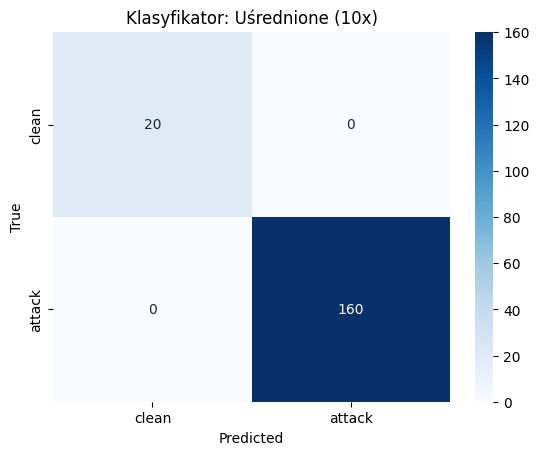

In [6]:
X_avg, y_avg = [], []
CHUNK_SIZE = 10

print(f"\nUśrednianie sygnatur po {CHUNK_SIZE} elementów...")
for cls in classes:
    # Wyciągamy indeksy wszystkich modeli dla tej KONTRETNEJ klasy
    idx_list = [i for i, p in enumerate(paths_all) if p[0] == cls]
    
    # Mieszamy indeksy, aby uśredniać losowe kombinacje modeli z tej samej klasy
    np.random.shuffle(idx_list)
    
    # Dzielimy na paczki po 10
    for i in range(0, len(idx_list), CHUNK_SIZE):
        chunk = idx_list[i : i + CHUNK_SIZE]
        
        # Pomiń resztki (np. jeśli zostało tylko 4 modeli na końcu, ignorujemy je)
        if len(chunk) < CHUNK_SIZE:
            continue 
            
        # Obliczamy średnią z tych 10 sygnatur (axis=0 zachowuje 630 cech)
        X_avg.append(np.mean(X[chunk], axis=0))
        y_avg.append(0 if cls == 'clean' else 1)

X_avg = np.array(X_avg)
y_avg = np.array(y_avg)

print(f'Nowy uśredniony X shape: {X_avg.shape}, clean: {(y_avg==0).sum()}, attack: {(y_avg==1).sum()}')

# ==========================================
# 3. Trening Klasyfikatora (Keras / TensorFlow)
# ==========================================
# Zmieniono X i y na X_avg i y_avg
X_train, X_test, y_train, y_test = train_test_split(X_avg, y_avg, test_size=0.2, random_state=42, stratify=y_avg)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

def build_keras_classifier(input_dim, fc_hidden=64, dropout_rate1=0.2, dropout_rate2=0.1):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_dim,)),
        
        tf.keras.layers.Dense(fc_hidden, activation='gelu'),
        tf.keras.layers.Dropout(dropout_rate1),
        
        tf.keras.layers.Dense(max(fc_hidden // 2, 16), activation='gelu'),
        tf.keras.layers.Dropout(dropout_rate2),
        
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

input_dim = X_train_s.shape[1] 
clf_model = build_keras_classifier(input_dim)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("\nRozpoczynam trening w Keras na uśrednionych danych...")
history = clf_model.fit(
    X_train_s, y_train,
    validation_split=0.15, 
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. Ewaluacja i Raport
# ==========================================
y_pred_probs = clf_model.predict(X_test_s).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

print("\n--- Raport Klasyfikatora na uśrednionych grupach (Keras) ---")
print(classification_report(y_test, y_pred, target_names=['clean', 'attack']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'attack'],
            yticklabels=['clean', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Klasyfikator: Uśrednione (10x)')
plt.show()

              precision    recall  f1-score   support

       clean       0.70      0.53      0.60        40
      attack       0.94      0.97      0.96       320

    accuracy                           0.92       360
   macro avg       0.82      0.75      0.78       360
weighted avg       0.92      0.92      0.92       360



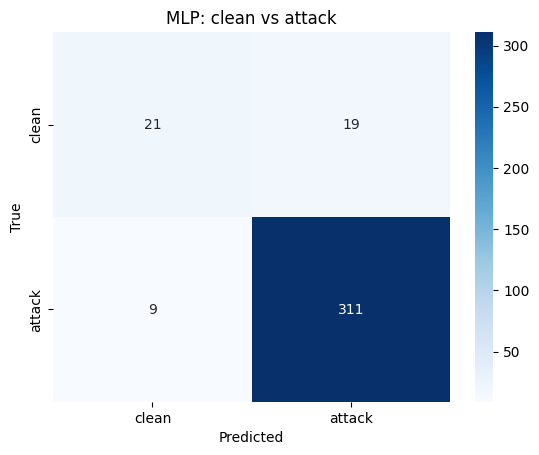

In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=300,
    random_state=42
)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=['clean', 'attack']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'attack'],
            yticklabels=['clean', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MLP: clean vs attack')
plt.show()

# Zad 3

In [7]:
import tensorflow as tf
def extract_signatures(path):
    m = load_model_from_path(path)
    
    # We will use the BATCH_INP defined globally in the previous script.
    # Convert to TF tensors for manual layer passing
    I_0_tensor = tf.convert_to_tensor(np.zeros((1, 21, 3), dtype=np.float32))
    batch_inp_tensor = tf.convert_to_tensor(BATCH_INP)
    
    # ==========================================
    # 1. Ręczne przejście przez warstwy (Bypass grafu)
    # m.layers[:-1] oznacza: weź wszystkie warstwy OPRÓCZ ostatniej (Dense_5).
    # Przechodzimy przez Flatten_2 -> Dense_4 i zatrzymujemy się.
    # ==========================================
    
    # Baseline (I_0) dla ukrytej warstwy
    h_I0 = I_0_tensor
    for layer in m.layers[:-1]:
        h_I0 = layer(h_I0, training=False)
    h_I0 = h_I0.numpy()  # Kształt: (1, 16)
    
    # Pełny batch 63 pikseli dla ukrytej warstwy
    h_Iij = batch_inp_tensor
    for layer in m.layers[:-1]:
        h_Iij = layer(h_Iij, training=False)
    h_Iij = h_Iij.numpy()  # Kształt: (63, 16)
    
    # ==========================================
    # 2. Finalne predykcje z całego modelu
    # ==========================================
    preds = m.predict(BATCH_INP, verbose=0) # Kształt: (63, 10)
    
    # ==========================================
    # 3. Obliczenia różnic i formatowanie (Zadanie 3)
    # ==========================================
    H_ij = h_Iij - h_I0 
    
    H_map = H_ij.reshape(21, 3, 16) 
    S_map = preds.reshape(21, 3, 10)  
    
    # Czyszczenie pamięci po modelu
    import gc
    del m
    tf.keras.backend.clear_session()
    gc.collect()
    
    return H_map, S_map

In [8]:
def plot_propagation_norms(H_maps_dict):

    n_models = len(H_maps_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(3 * n_models, 6), constrained_layout=True)
    fig.suptitle('Norma ||H(i,j)|| - Wpływ pikseli na warstwę ukrytą', fontsize=14, fontweight='bold')
    
    if n_models == 1:
        axes = [axes]
        
    for ax, (name, H_map) in zip(axes, H_maps_dict.items()):
        # Calculate L2 norm across the 16 hidden neurons for each pixel
        # Resulting shape: (21, 3)
        H_norm = np.linalg.norm(H_map, axis=-1) 
        
        im = ax.imshow(H_norm, cmap='hot', aspect='auto')
        ax.set_title(name)
        ax.axis('off')
        fig.colorbar(im, ax=ax, shrink=0.8)
        
    plt.show()

In [9]:
def plot_neuron_profile(H_maps_dict, pixel_i, pixel_j):
    """
    Plots the 16-dimensional vector for a specific pixel (i, j) across models.
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    
    x = np.arange(16) # 16 neurons
    width = 0.8 / len(H_maps_dict)
    
    for idx, (name, H_map) in enumerate(H_maps_dict.items()):
        # Extract the 16-dim vector for the specific pixel
        neuron_vals = H_map[pixel_i, pixel_j, :] 
        
        offset = (idx - len(H_maps_dict)/2) * width + width/2
        ax.bar(x + offset, neuron_vals, width, label=name)
        
    ax.set_title(f'Wartości H(i,j) w warstwie ukrytej dla piksela ({pixel_i}, {pixel_j})')
    ax.set_xlabel('Indeks neuronu ukrytego (0-15)')
    ax.set_ylabel('Różnica aktywacji vs I_0')
    ax.set_xticks(x)
    ax.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [4]:

classes = ['clean'] + ATTACK_NAMES
n_pixels = 21 * 3
BATCH_INP = np.zeros((n_pixels, 21, 3), dtype=np.float32)
idx = 0
for i in range(21):
    for j in range(3):
        BATCH_INP[idx, i, j] = 1.0
        idx += 1

Rozpoczynam ekstrakcję map propagacji i sygnatur wyjściowych...
Ukończono. Kształt H_maps_all: (9000, 21, 3, 16)

Generowanie map norm ||H(i,j)||...


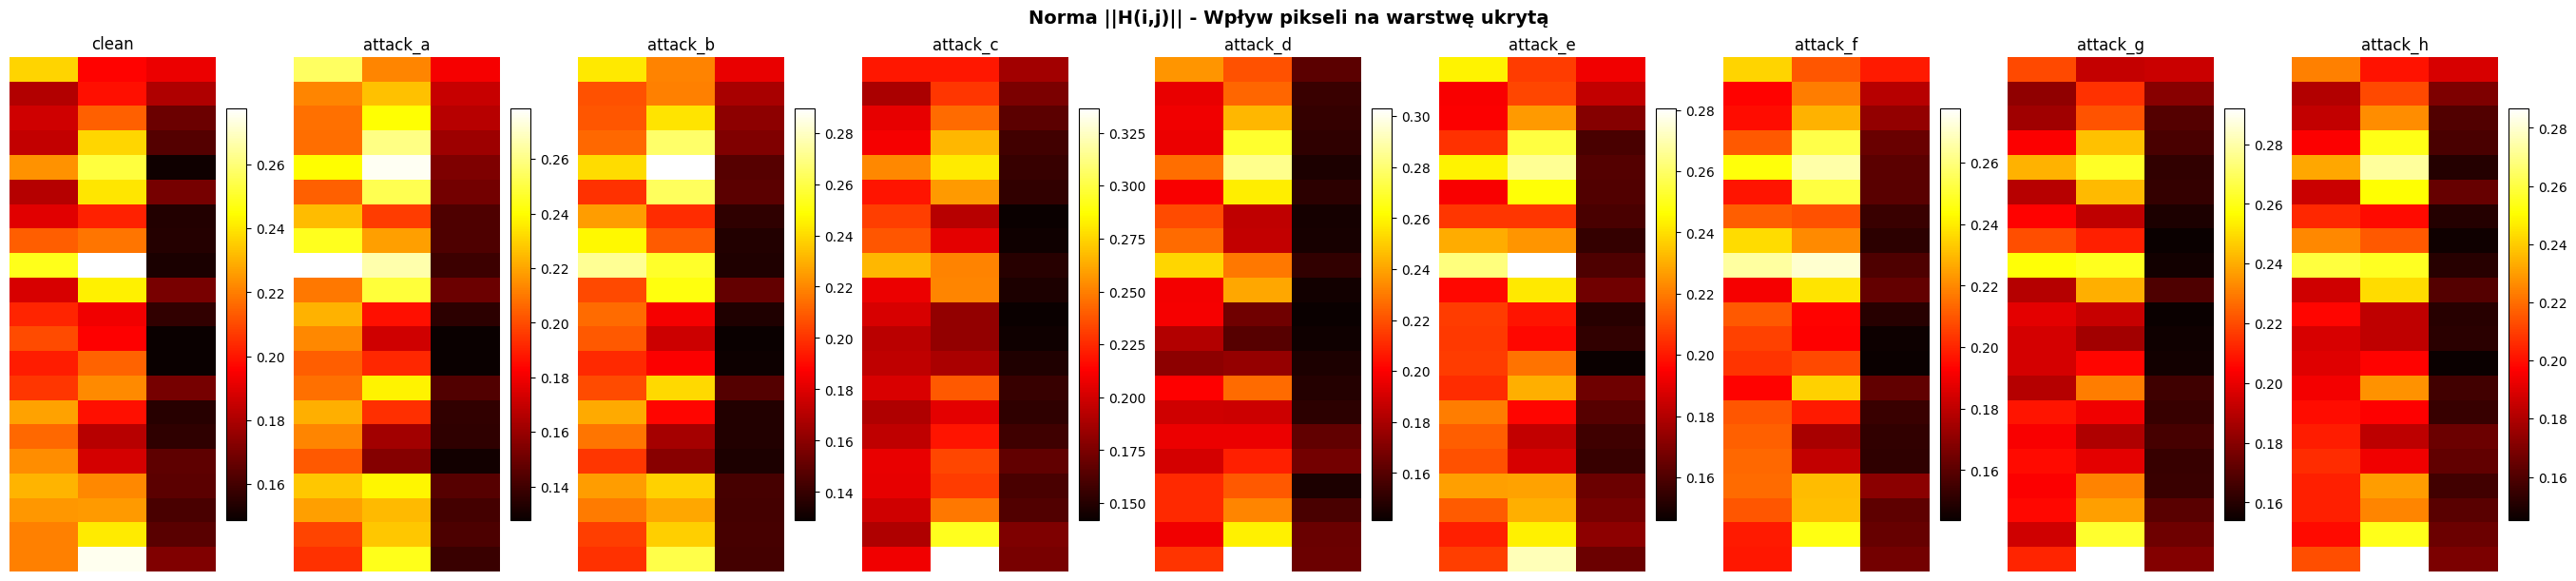


Generowanie profilu neuronów dla piksela (20, 2)...


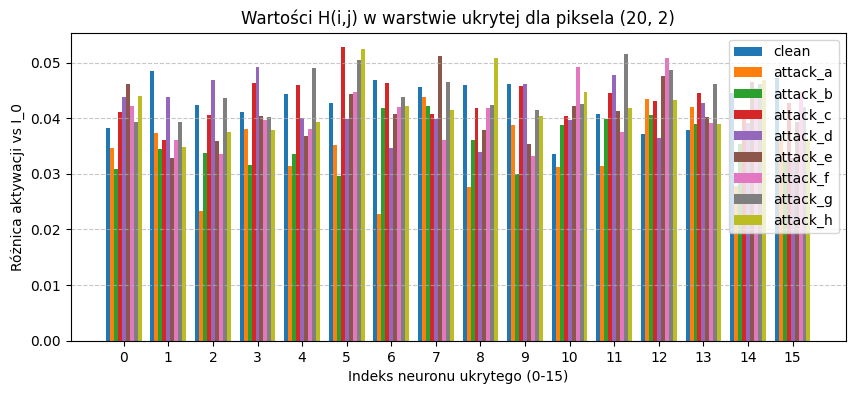

In [13]:
H_maps_all = []
S_maps_all = []
paths_all = []

# ==========================================
# 2. Główna pętla ekstrakcji (zaktualizowana pod *.png)
# ==========================================
print("Rozpoczynam ekstrakcję map propagacji i sygnatur wyjściowych...")

for cls in classes:
    # Wczytywanie plików *.png zgodnie z Twoją metodą
    files = sorted((DATA_ROOT / cls).glob('*.png'))
    
    for p in files:
        # Przekazujemy ścieżkę pliku .png do funkcji ekstrakcyjnej
        # Uwaga: upewnij się, że hidden_layer_index=-2 to poprawne miejsce warstwy Dense(16)
        H_map, S_map = extract_signatures(p) 
        
        H_maps_all.append(H_map)
        S_maps_all.append(S_map)
        paths_all.append((cls, p.name))

# Konwersja na tablice NumPy dla ułatwienia obliczeń na maskach
H_maps_all = np.array(H_maps_all) # Kształt: (Liczba_modeli, 21, 3, 16)
S_maps_all = np.array(S_maps_all) # Kształt: (Liczba_modeli, 21, 3, 10)

print(f"Ukończono. Kształt H_maps_all: {H_maps_all.shape}")

# ==========================================
# 3. Agregacja (Obliczanie średniej per klasa)
# ==========================================
avg_H_per_cls = {}
avg_S_per_cls = {}

for cls in classes:
    mask = np.array([1 if path_info[0] == cls else 0 for path_info in paths_all], dtype=bool)
    
    if mask.any():
        avg_H_per_cls[cls] = H_maps_all[mask].mean(axis=0)
        avg_S_per_cls[cls] = S_maps_all[mask].mean(axis=0)

# ==========================================
# 4. Generowanie Wizualizacji
# ==========================================
print("\nGenerowanie map norm ||H(i,j)||...")
plot_propagation_norms(avg_H_per_cls)

# Zmień target_i oraz target_j na piksel, który wyraźnie aktywuje się na mapie norm dla modeli "brudnych"
target_i, target_j = 20, 2 

print(f"\nGenerowanie profilu neuronów dla piksela ({target_i}, {target_j})...")
if avg_H_per_cls:
    plot_neuron_profile(avg_H_per_cls, target_i, target_j)

## 200 klas

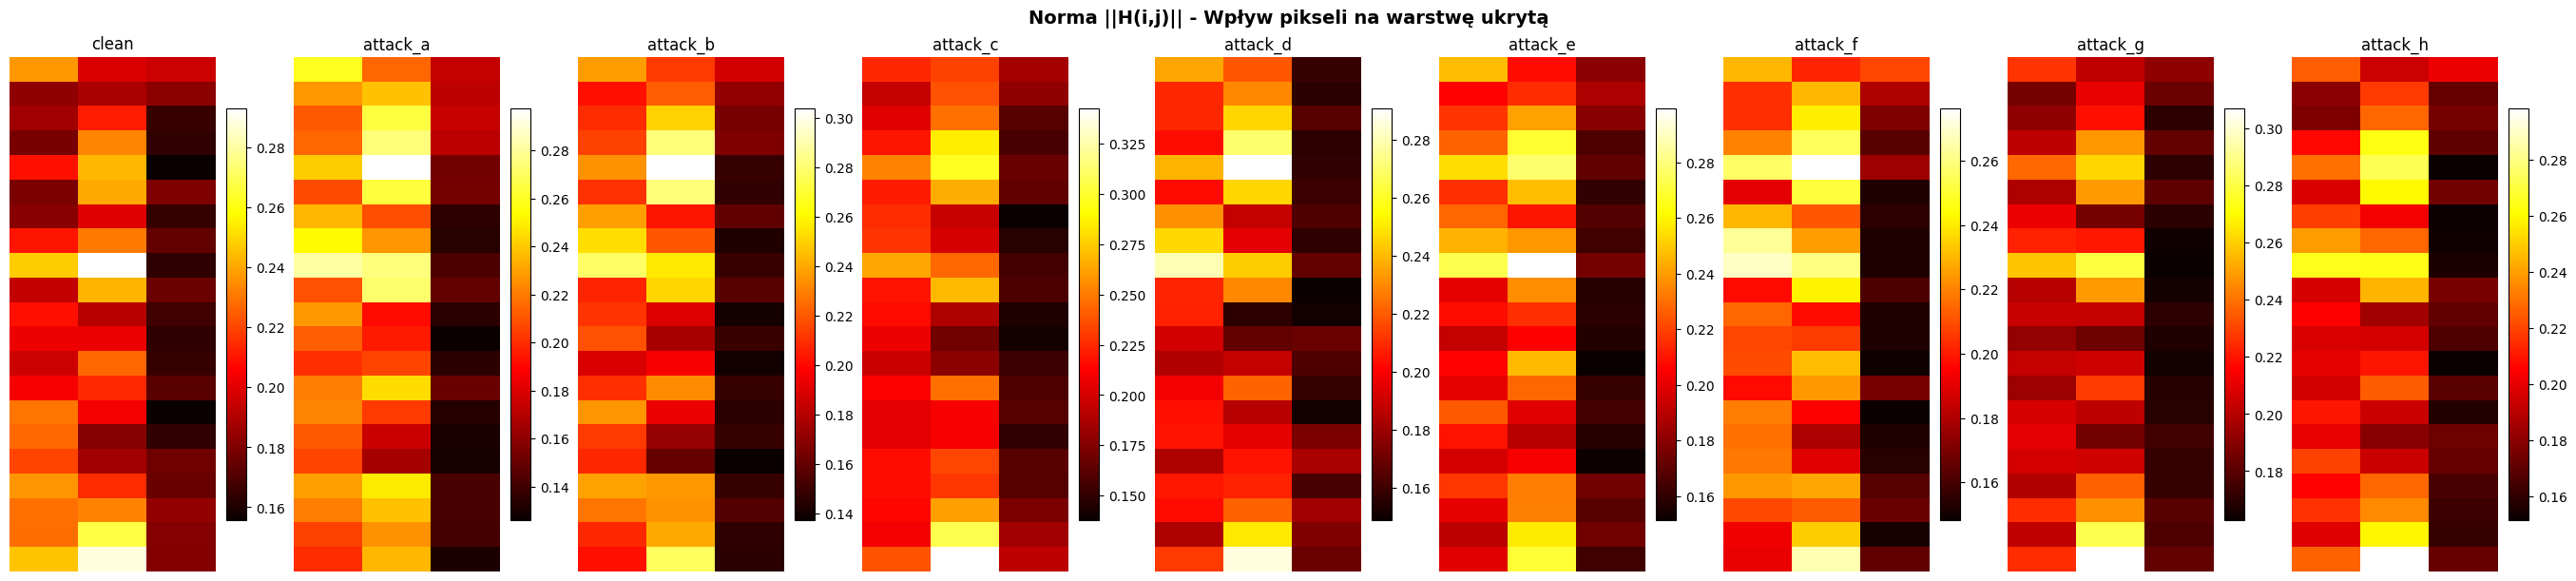

In [19]:

plot_propagation_norms(avg_H_per_cls)



Generowanie profilu neuronów dla piksela (0, 1)...


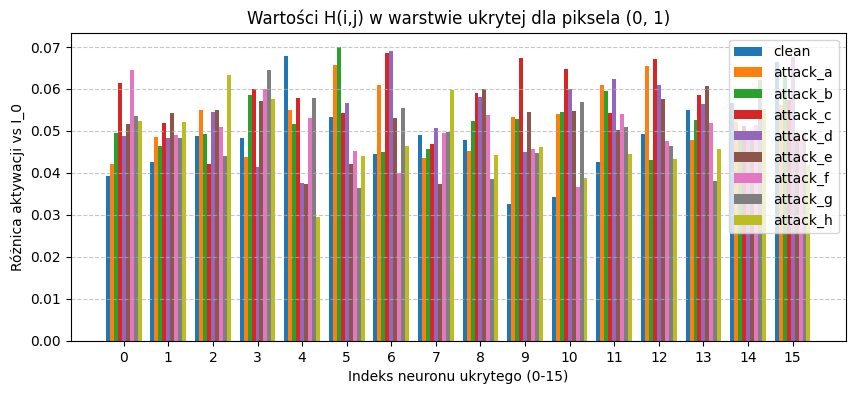


Generowanie profilu neuronów dla piksela (7, 0)...


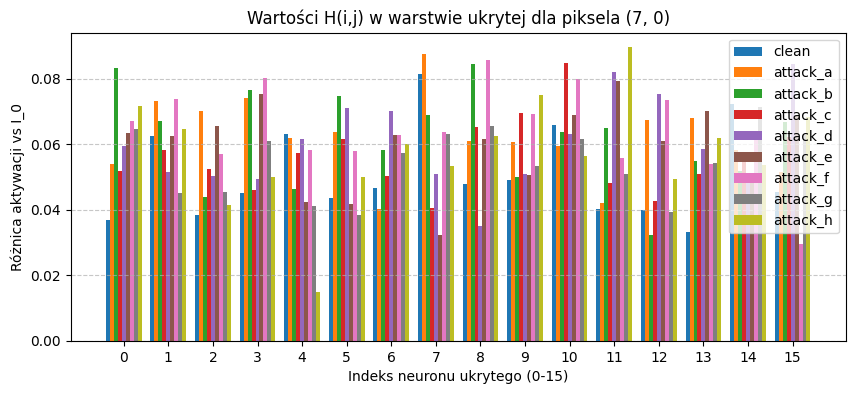


Generowanie profilu neuronów dla piksela (4, 1)...


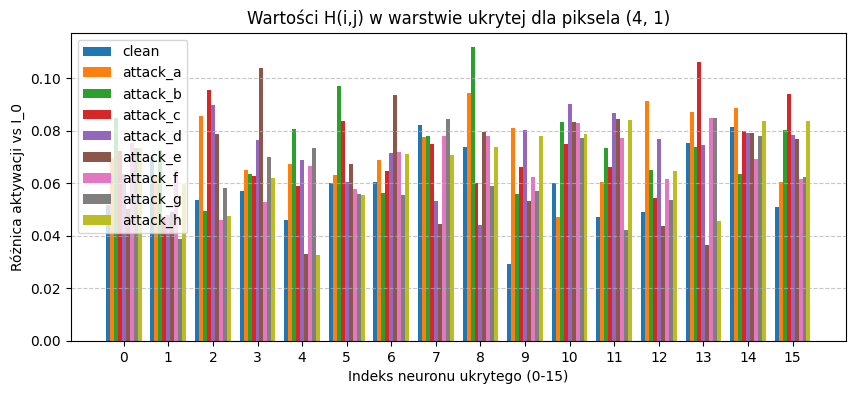


Generowanie profilu neuronów dla piksela (20, 0)...


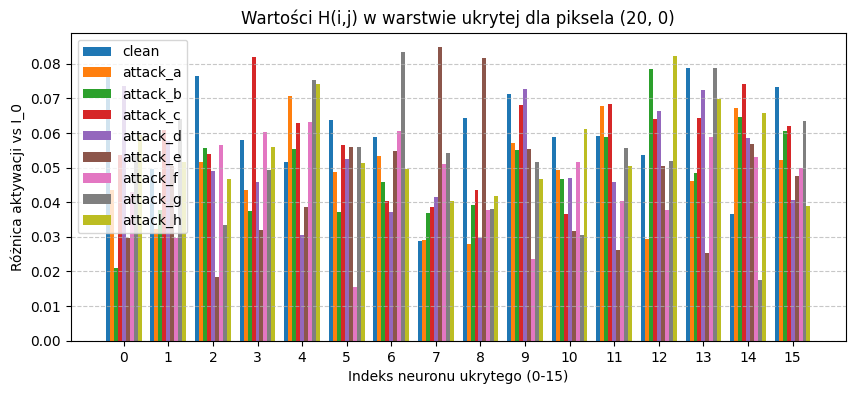

In [24]:

target_i, target_j = 0, 1

print(f"\nGenerowanie profilu neuronów dla piksela ({target_i}, {target_j})...")
if avg_H_per_cls:
    plot_neuron_profile(avg_H_per_cls, target_i, target_j)


target_i, target_j = 7, 0

print(f"\nGenerowanie profilu neuronów dla piksela ({target_i}, {target_j})...")
if avg_H_per_cls:
    plot_neuron_profile(avg_H_per_cls, target_i, target_j)



target_i, target_j = 4, 1

print(f"\nGenerowanie profilu neuronów dla piksela ({target_i}, {target_j})...")
if avg_H_per_cls:
    plot_neuron_profile(avg_H_per_cls, target_i, target_j)



target_i, target_j = 20, 0

print(f"\nGenerowanie profilu neuronów dla piksela ({target_i}, {target_j})...")
if avg_H_per_cls:
    plot_neuron_profile(avg_H_per_cls, target_i, target_j)    

# Klasyfikatory dla wszystkich danych

In [5]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


def extract_signatures_h(path):
    m = load_model_from_path(path)
    
    I_0_tensor = tf.convert_to_tensor(np.zeros((1, 21, 3), dtype=np.float32))
    batch_inp_tensor = tf.convert_to_tensor(BATCH_INP)
    

    h_I0 = I_0_tensor
    for layer in m.layers[:-1]:
        h_I0 = layer(h_I0, training=False)
    h_I0 = h_I0.numpy()  
    
    h_Iij = batch_inp_tensor
    for layer in m.layers[:-1]:
        h_Iij = layer(h_Iij, training=False)
    h_Iij = h_Iij.numpy()  
        

    H_ij = h_Iij - h_I0 
    
    H_map = H_ij.reshape(21, 3, 16) 
    
    import gc
    del m
    tf.keras.backend.clear_session()
    gc.collect()
    
    return H_map

H_maps_all = []
paths_all = []


print("Rozpoczynam ekstrakcję map propagacji i sygnatur wyjściowych...")

for cls in classes:
    files = sorted((DATA_ROOT / cls).glob('*.png'))
    
    for i, p in enumerate(files):
        if i % 50 == 0:
            print(f"Przetwarzam {cls}: {i}/{len(files)}")
       
        H_map = extract_signatures_h(p)
        
        H_maps_all.append(H_map)
        paths_all.append((cls, p.name))

    np.save(f'H_maps_{cls}.npy', np.array(H_maps_all))    

H_maps_all = np.array(H_maps_all) 
np.save('H_maps_all.npy', H_maps_all)

print(f"Ukończono. Kształt H_maps_all: {H_maps_all.shape}")

Physical devices cannot be modified after being initialized
Rozpoczynam ekstrakcję map propagacji i sygnatur wyjściowych...
Przetwarzam clean: 0/1000
Przetwarzam clean: 50/1000
Przetwarzam clean: 100/1000
Przetwarzam clean: 150/1000
Przetwarzam clean: 200/1000
Przetwarzam clean: 250/1000
Przetwarzam clean: 300/1000
Przetwarzam clean: 350/1000
Przetwarzam clean: 400/1000
Przetwarzam clean: 450/1000
Przetwarzam clean: 500/1000
Przetwarzam clean: 550/1000
Przetwarzam clean: 600/1000
Przetwarzam clean: 650/1000
Przetwarzam clean: 700/1000
Przetwarzam clean: 750/1000
Przetwarzam clean: 800/1000
Przetwarzam clean: 850/1000
Przetwarzam clean: 900/1000
Przetwarzam clean: 950/1000
Przetwarzam attack_a: 0/1000
Przetwarzam attack_a: 50/1000
Przetwarzam attack_a: 100/1000
Przetwarzam attack_a: 150/1000
Przetwarzam attack_a: 200/1000
Przetwarzam attack_a: 250/1000
Przetwarzam attack_a: 300/1000
Przetwarzam attack_a: 350/1000
Przetwarzam attack_a: 400/1000
Przetwarzam attack_a: 450/1000
Przetwarzam 


Obliczanie normy L2 dla wszystkich map propagacji...
Dane wejściowe X_h gotowe. Kształt: (9000, 63), Etykiety: clean=1000, attack=8000

TRENING 1: KLASYFIKATOR INDYWIDUALNYCH MODELI
Epoch 1/20


/home/agagro/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1782339911.264687    1900 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_917910__.11


176/192 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8461 - loss: 0.4293

I0000 00:00:1782339912.672301    1900 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_917910__.11


192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8716 - loss: 0.3928 - val_accuracy: 0.8926 - val_loss: 0.3237
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8879 - loss: 0.3440 - val_accuracy: 0.8917 - val_loss: 0.3096
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8881 - loss: 0.3251 - val_accuracy: 0.8917 - val_loss: 0.3040
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8868 - loss: 0.3094 - val_accuracy: 0.8917 - val_loss: 0.3033
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8889 - loss: 0.3074 - val_accuracy: 0.8917 - val_loss: 0.3017
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8891 - loss: 0.2961 - val_accuracy: 0.8917 - val_loss: 0.3019
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8912 - loss: 0.2900 - val_accuracy: 0.8917 - val_loss: 0.3023
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8904 - loss: 0.2917 - val_accuracy: 0.8917 - val

...

Epoch 1/20


I0000 00:00:1782339921.068403    1900 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_933482__.11


36/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5053 - loss: 0.7790

I0000 00:00:1782339922.033632    1903 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_933482__.11


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6111 - loss: 0.6857 - val_accuracy: 0.8148 - val_loss: 0.5289
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8431 - loss: 0.4530 - val_accuracy: 0.8704 - val_loss: 0.3992
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8725 - loss: 0.3784 - val_accuracy: 0.8796 - val_loss: 0.3195
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8938 - loss: 0.2949 - val_accuracy: 0.8796 - val_loss: 0.2681
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8954 - loss: 0.2591 - val_accuracy: 0.8796 - val_loss: 0.2381
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8987 - loss: 0.2342 - val_accuracy: 0.8796 - val_loss: 0.2180
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9167 - loss: 0.1971 - val_accuracy: 0.8796 - val_loss: 0.2021
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9297 - loss: 0.1737 - val_accuracy: 0.8889 - val_loss: 0.1907
Ep

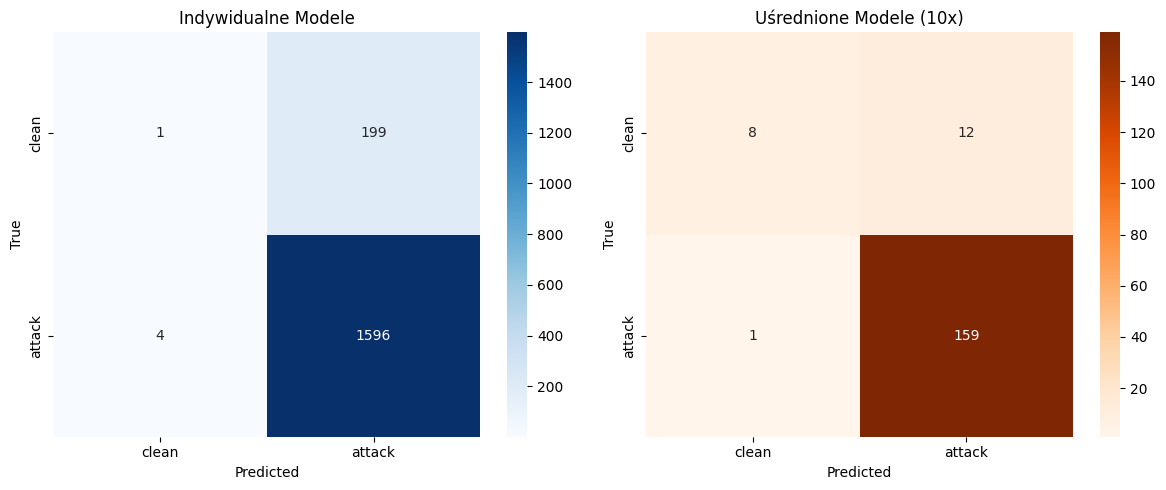

In [10]:
# ==========================================
# 5. Przygotowanie i Normalizacja Danych (L2 Norm)
# ==========================================
print("\nObliczanie normy L2 dla wszystkich map propagacji...")

# Zakładamy, że H_maps_all ma kształt (N, 21, 3, 16)
# Obliczamy normę L2 na ostatniej osi, dokładnie jak w Twojej funkcji rysującej.
# Nowy kształt: (N, 21, 3)
H_norm_all = np.linalg.norm(H_maps_all, axis=-1)

# Spłaszczamy (21, 3) do 63 cech per model dla Keras
X_h = H_norm_all.reshape(H_norm_all.shape[0], -1)

# Generowanie etykiet (0 = clean, 1 = attack) na podstawie paths_all
y_h = np.array([0 if p[0] == 'clean' else 1 for p in paths_all])

print(f"Dane wejściowe X_h gotowe. Kształt: {X_h.shape}, Etykiety: clean={(y_h==0).sum()}, attack={(y_h==1).sum()}")


# Wspólna funkcja do budowy modelu klasyfikatora
def build_keras_classifier(input_dim, fc_hidden=32, dropout_rate=0.2):
    # Użyto nieco mniejszej warstwy ukrytej (32), 
    # ponieważ mamy teraz tylko 63 cechy zamiast 630.
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_dim,)),
        tf.keras.layers.Dense(fc_hidden, activation='gelu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(max(fc_hidden // 2, 8), activation='gelu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# ==========================================
# 6. Klasyfikator 1: Indywidualne Modele
# ==========================================
print("\n" + "="*50)
print("TRENING 1: KLASYFIKATOR INDYWIDUALNYCH MODELI")
print("="*50)

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h
)

scaler_1 = StandardScaler()
X_train_1_s = scaler_1.fit_transform(X_train_1)
X_test_1_s  = scaler_1.transform(X_test_1)

clf_indiv = build_keras_classifier(X_train_1_s.shape[1])

clf_indiv.fit(
    X_train_1_s, y_train_1,
    validation_split=0.15, 
    epochs=20, batch_size=32, 
    callbacks=[early_stop], verbose=1
)

# Ewaluacja Indywidualna
y_pred_probs_1 = clf_indiv.predict(X_test_1_s).flatten()
y_pred_1 = (y_pred_probs_1 >= 0.5).astype(int)

print("\n--- Raport: Indywidualne Modele (H_maps L2) ---")
print(classification_report(y_test_1, y_pred_1, target_names=['clean', 'attack']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_1 = confusion_matrix(y_test_1, y_pred_1)
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['clean', 'attack'], yticklabels=['clean', 'attack'])
axes[0].set_title('Indywidualne Modele')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# ==========================================
# 7. Przygotowanie Uśrednionych Danych (Paczki x10)
# ==========================================
X_avg, y_avg = [], []
CHUNK_SIZE = 10

print(f"\nUśrednianie znormalizowanych map po {CHUNK_SIZE} elementów...")
for cls in classes:
    idx_list = [i for i, p in enumerate(paths_all) if p[0] == cls]
    np.random.shuffle(idx_list)
    
    for i in range(0, len(idx_list), CHUNK_SIZE):
        chunk = idx_list[i : i + CHUNK_SIZE]
        
        # Odrzucamy resztki, aby każda próbka miała równo 10 elementów
        if len(chunk) < CHUNK_SIZE:
            continue 
            
        X_avg.append(np.mean(X_h[chunk], axis=0))
        y_avg.append(0 if cls == 'clean' else 1)

X_avg = np.array(X_avg)
y_avg = np.array(y_avg)

print(f'Nowy uśredniony zbiór X_avg shape: {X_avg.shape}, clean: {(y_avg==0).sum()}, attack: {(y_avg==1).sum()}')

# ==========================================
# 8. Klasyfikator 2: Uśrednione Paczki (10x)
# ==========================================
print("\n" + "="*50)
print("TRENING 2: KLASYFIKATOR UŚREDNIONYCH PACZEK (10x)")
print("="*50)

# Używamy mniejszego test_size jeśli uśrednianie drastycznie zmniejszyło zbiór danych
test_ratio = 0.2 if len(X_avg) > 50 else 0.3 
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_avg, y_avg, test_size=test_ratio, random_state=42, stratify=y_avg
)

scaler_2 = StandardScaler()
X_train_2_s = scaler_2.fit_transform(X_train_2)
X_test_2_s  = scaler_2.transform(X_test_2)

clf_avg = build_keras_classifier(X_train_2_s.shape[1])

# Zmniejszamy batch_size dla uśrednionych danych (ponieważ zbiór jest 10x mniejszy)
clf_avg.fit(
    X_train_2_s, y_train_2,
    validation_split=0.15, 
    epochs=20, batch_size=16, 
    callbacks=[early_stop], verbose=1
)

# Ewaluacja Uśredniona
y_pred_probs_2 = clf_avg.predict(X_test_2_s).flatten()
y_pred_2 = (y_pred_probs_2 >= 0.5).astype(int)

print("\n--- Raport: Uśrednione Modele (10x) (H_maps L2) ---")
print(classification_report(y_test_2, y_pred_2, target_names=['clean', 'attack']))

cm_2 = confusion_matrix(y_test_2, y_pred_2)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['clean', 'attack'], yticklabels=['clean', 'attack'])
axes[1].set_title('Uśrednione Modele (10x)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()


Uśrednianie znormalizowanych map po 20 elementów...
Nowy uśredniony zbiór X_avg shape: (450, 63), clean: 50, attack: 400

TRENING 2: KLASYFIKATOR UŚREDNIONYCH PACZEK (20x)
Epoch 1/20


/home/agagro/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1782340367.909169    1901 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_947343__.11


16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5205 - loss: 0.7711

I0000 00:00:1782340368.790996    1903 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_947343__.11


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5686 - loss: 0.7030 - val_accuracy: 0.8519 - val_loss: 0.4641
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8105 - loss: 0.4680 - val_accuracy: 0.9074 - val_loss: 0.3374
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8758 - loss: 0.3505 - val_accuracy: 0.9074 - val_loss: 0.2643
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9118 - loss: 0.2978 - val_accuracy: 0.9074 - val_loss: 0.2189
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9216 - loss: 0.2610 - val_accuracy: 0.9444 - val_loss: 0.1893
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

--- Raport: Uśrednione Modele (20x) (H_maps L2) ---
              precision    recall  f1-score   support

       clean       0.14      0.30      0.19        10
      attack       0.90      0.76      0.82        80

    accuracy                           0.71        90
   macro avg       0.52      0.53      0.51        90
weighted avg     

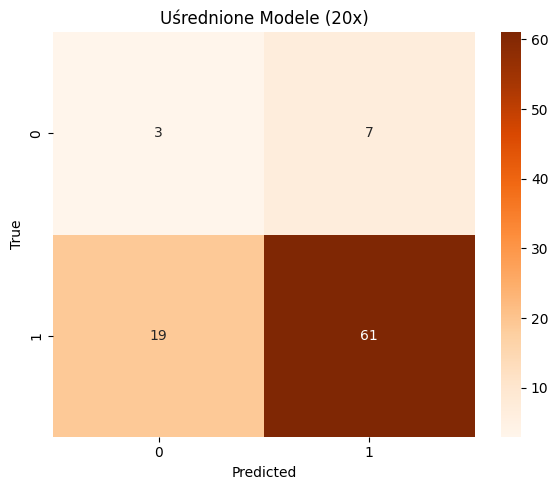

In [14]:
X_avg, y_avg = [], []
CHUNK_SIZE = 20

print(f"\nUśrednianie znormalizowanych map po {CHUNK_SIZE} elementów...")
for cls in classes:
    idx_list = [i for i, p in enumerate(paths_all) if p[0] == cls]
    np.random.shuffle(idx_list)
    
    for i in range(0, len(idx_list), CHUNK_SIZE):
        chunk = idx_list[i : i + CHUNK_SIZE]
        
        if len(chunk) < CHUNK_SIZE:
            continue 
            
        X_avg.append(np.mean(X_h[chunk], axis=0))
        y_avg.append(0 if cls == 'clean' else 1)

X_avg = np.array(X_avg)
y_avg = np.array(y_avg)

print(f'Nowy uśredniony zbiór X_avg shape: {X_avg.shape}, clean: {(y_avg==0).sum()}, attack: {(y_avg==1).sum()}')

# ==========================================
# 8. Klasyfikator 2: Uśrednione Paczki (10x)
# ==========================================
print("\n" + "="*50)
print("TRENING 2: KLASYFIKATOR UŚREDNIONYCH PACZEK (20x)")
print("="*50)

# Używamy mniejszego test_size jeśli uśrednianie drastycznie zmniejszyło zbiór danych
test_ratio = 0.2 if len(X_avg) > 50 else 0.3 
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_avg, y_avg, test_size=test_ratio, random_state=42, stratify=y_avg
)

scaler_2 = StandardScaler()
X_train_2_s = scaler_2.fit_transform(X_train_2)
X_test_2_s  = scaler_2.transform(X_test_2)

clf_avg = build_keras_classifier(X_train_2_s.shape[1])

# Zmniejszamy batch_size dla uśrednionych danych (ponieważ zbiór jest 20x mniejszy)
clf_avg.fit(
    X_train_2_s, y_train_2,
    validation_split=0.15, 
    epochs=20, batch_size=16, 
    callbacks=[early_stop], verbose=1
)

# Ewaluacja Uśredniona
y_pred_probs_2 = clf_avg.predict(X_test_2_s).flatten()
y_pred_2 = (y_pred_probs_2 >= 0.5).astype(int)

print("\n--- Raport: Uśrednione Modele (20x) (H_maps L2) ---")
print(classification_report(y_test_2, y_pred_2, target_names=['clean', 'attack']))

fig, ax = plt.subplots(figsize=(6, 5))
cm_2 = confusion_matrix(y_test_2, y_pred_2)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Oranges', ax=ax)
ax.set_title('Uśrednione Modele (20x)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.tight_layout()
plt.show()


Uśrednianie znormalizowanych map po 50 elementów...
Nowy uśredniony zbiór X_avg shape: (180, 63), clean: 20, attack: 160

TRENING 2: KLASYFIKATOR UŚREDNIONYCH PACZEK (50x)
Epoch 1/20


/home/agagro/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1782340390.764298    1900 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_950049__.11


1/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6250 - loss: 0.8772

I0000 00:00:1782340391.646924    1900 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_950049__.11


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.6066 - loss: 0.7139 - val_accuracy: 0.6364 - val_loss: 0.6860
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6803 - loss: 0.6026 - val_accuracy: 0.7727 - val_loss: 0.5836
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7869 - loss: 0.4873 - val_accuracy: 0.7727 - val_loss: 0.5063
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8279 - loss: 0.4150 - val_accuracy: 0.8182 - val_loss: 0.4433
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8525 - loss: 0.3744 - val_accuracy: 0.8182 - val_loss: 0.3936
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step

--- Raport: Uśrednione Modele (50x) (H_maps L2) ---
              precision    recall  f1-score   support

       clean       0.33      1.00      0.50         4
      attack       1.00      0.75      0.86        32

    accuracy                           0.78        36
   macro avg       0.67      0.88      0.68        36
weighted avg       0.93

Text(45.722222222222214, 0.5, 'True')

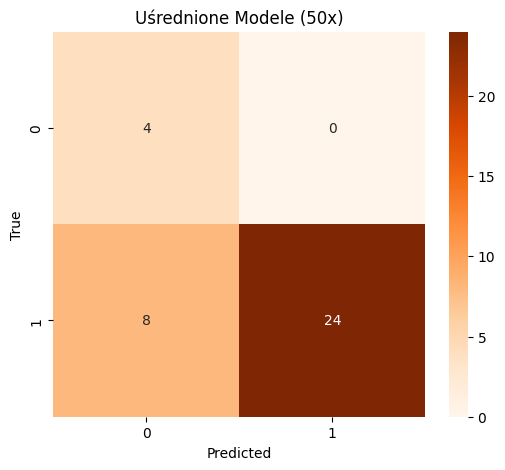

In [15]:
X_avg, y_avg = [], []
CHUNK_SIZE = 50

print(f"\nUśrednianie znormalizowanych map po {CHUNK_SIZE} elementów...")
for cls in classes:
    idx_list = [i for i, p in enumerate(paths_all) if p[0] == cls]
    np.random.shuffle(idx_list)
    
    for i in range(0, len(idx_list), CHUNK_SIZE):
        chunk = idx_list[i : i + CHUNK_SIZE]
        
        # Odrzucamy resztki, aby każda próbka miała równo 10 elementów
        if len(chunk) < CHUNK_SIZE:
            continue 
            
        X_avg.append(np.mean(X_h[chunk], axis=0))
        y_avg.append(0 if cls == 'clean' else 1)

X_avg = np.array(X_avg)
y_avg = np.array(y_avg)

print(f'Nowy uśredniony zbiór X_avg shape: {X_avg.shape}, clean: {(y_avg==0).sum()}, attack: {(y_avg==1).sum()}')

# ==========================================
# 8. Klasyfikator 2: Uśrednione Paczki (50x)
# ==========================================
print("\n" + "="*50)
print("TRENING 2: KLASYFIKATOR UŚREDNIONYCH PACZEK (50x)")
print("="*50)

# Używamy mniejszego test_size jeśli uśrednianie drastycznie zmniejszyło zbiór danych
test_ratio = 0.2 if len(X_avg) > 50 else 0.3 
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_avg, y_avg, test_size=test_ratio, random_state=42, stratify=y_avg
)

scaler_2 = StandardScaler()
X_train_2_s = scaler_2.fit_transform(X_train_2)
X_test_2_s  = scaler_2.transform(X_test_2)

clf_avg = build_keras_classifier(X_train_2_s.shape[1])

# Zmniejszamy batch_size dla uśrednionych danych (ponieważ zbiór jest 50x mniejszy)
clf_avg.fit(
    X_train_2_s, y_train_2,
    validation_split=0.15, 
    epochs=20, batch_size=16, 
    callbacks=[early_stop], verbose=1
)

# Ewaluacja Uśredniona
y_pred_probs_2 = clf_avg.predict(X_test_2_s).flatten()
y_pred_2 = (y_pred_probs_2 >= 0.5).astype(int)

print("\n--- Raport: Uśrednione Modele (50x) (H_maps L2) ---")
print(classification_report(y_test_2, y_pred_2, target_names=['clean', 'attack']))

fig, ax = plt.subplots(figsize=(6, 5))
cm_2 = confusion_matrix(y_test_2, y_pred_2)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Oranges', ax=ax)
ax.set_title('Uśrednione Modele (50x)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')


Uśrednianie znormalizowanych map po 100 elementów...
Nowy uśredniony zbiór X_avg shape: (90, 63), clean: 10, attack: 80

TRENING 2: KLASYFIKATOR UŚREDNIONYCH PACZEK (100x)
Epoch 1/20


/home/agagro/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1782340404.649878    1903 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_952468__.11


1/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3125 - loss: 0.9890

I0000 00:00:1782340405.481982    1901 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_952468__.11


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 578ms/step - accuracy: 0.3607 - loss: 0.8965 - val_accuracy: 0.2727 - val_loss: 0.8852
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3934 - loss: 0.8286 - val_accuracy: 0.4545 - val_loss: 0.8181
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4262 - loss: 0.7729 - val_accuracy: 0.5455 - val_loss: 0.7584
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5246 - loss: 0.6771 - val_accuracy: 0.5455 - val_loss: 0.7075
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5410 - loss: 0.6512 - val_accuracy: 0.5455 - val_loss: 0.6611
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step

--- Raport: Uśrednione Modele (100x) (H_maps L2) ---
              precision    recall  f1-score   support

       clean       0.29      1.00      0.44         2
      attack       1.00      0.69      0.81        16

    accuracy                           0.72        18
   macro avg       0.64      0.84      0.63        18
weighted avg       0

Text(45.722222222222214, 0.5, 'True')

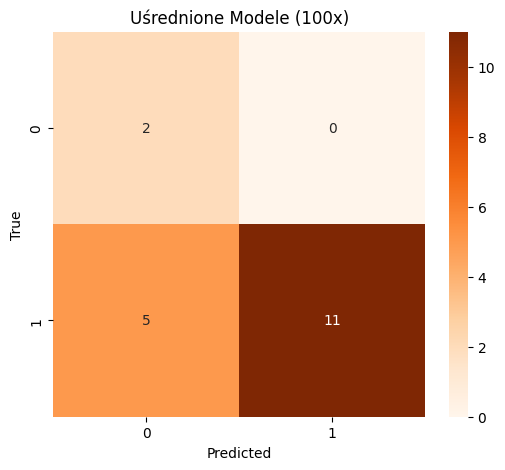

In [16]:
X_avg, y_avg = [], []
CHUNK_SIZE = 100

print(f"\nUśrednianie znormalizowanych map po {CHUNK_SIZE} elementów...")
for cls in classes:
    idx_list = [i for i, p in enumerate(paths_all) if p[0] == cls]
    np.random.shuffle(idx_list)
    
    for i in range(0, len(idx_list), CHUNK_SIZE):
        chunk = idx_list[i : i + CHUNK_SIZE]
        
        # Odrzucamy resztki, aby każda próbka miała równo 10 elementów
        if len(chunk) < CHUNK_SIZE:
            continue 
            
        X_avg.append(np.mean(X_h[chunk], axis=0))
        y_avg.append(0 if cls == 'clean' else 1)

X_avg = np.array(X_avg)
y_avg = np.array(y_avg)

print(f'Nowy uśredniony zbiór X_avg shape: {X_avg.shape}, clean: {(y_avg==0).sum()}, attack: {(y_avg==1).sum()}')

# ==========================================
# 8. Klasyfikator 2: Uśrednione Paczki (100x)
# ==========================================
print("\n" + "="*50)
print("TRENING 2: KLASYFIKATOR UŚREDNIONYCH PACZEK (100x)")
print("="*50)

# Używamy mniejszego test_size jeśli uśrednianie drastycznie zmniejszyło zbiór danych
test_ratio = 0.2 if len(X_avg) > 50 else 0.3 
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_avg, y_avg, test_size=test_ratio, random_state=42, stratify=y_avg
)

scaler_2 = StandardScaler()
X_train_2_s = scaler_2.fit_transform(X_train_2)
X_test_2_s  = scaler_2.transform(X_test_2)

clf_avg = build_keras_classifier(X_train_2_s.shape[1])

# Zmniejszamy batch_size dla uśrednionych danych (ponieważ zbiór jest 100x mniejszy)
clf_avg.fit(
    X_train_2_s, y_train_2,
    validation_split=0.15, 
    epochs=20, batch_size=16, 
    callbacks=[early_stop], verbose=1
)

# Ewaluacja Uśredniona
y_pred_probs_2 = clf_avg.predict(X_test_2_s).flatten()
y_pred_2 = (y_pred_probs_2 >= 0.5).astype(int)

print("\n--- Raport: Uśrednione Modele (100x) (H_maps L2) ---")
print(classification_report(y_test_2, y_pred_2, target_names=['clean', 'attack']))

fig, ax = plt.subplots(figsize=(6, 5))
cm_2 = confusion_matrix(y_test_2, y_pred_2)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Oranges', ax=ax)
ax.set_title('Uśrednione Modele (100x)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')